In [1]:
# !git clone https://github.com/recepgul82/music-digital-methods.git
# !pip install -r music-digital-methods/setup/requirements.txt

In [ ]:
import sys
from pathlib import Path

def find_repo_root(marker_dir="course_code"):
    # Search upward from current working directory first
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / marker_dir).is_dir():
            return p
        if p == p.parent:
            break
        p = p.parent

    # If not found, search common top locations (e.g., Colab /content) without hardcoding repo name
    for base in [Path("/content"), Path.cwd().resolve()]:
        if base.exists():
            for candidate in base.rglob(marker_dir):
                if candidate.is_dir():
                    return candidate.parent

    raise RuntimeError(f"Could not locate repo root containing '{marker_dir}/'.")

REPO_ROOT = find_repo_root("course_code")
print("REPO_ROOT =", REPO_ROOT)

sys.path.insert(0, str(REPO_ROOT))


REPO_ROOT = /Users/recepgul/Desktop/ITU/Teaching/Doktora/LEE904E/music-digital-methods


In [16]:
import os
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

data_path = os.path.join(REPO_ROOT, "data/mxmh_survey_results.csv")
mental_health = pd.read_csv(data_path)
mental_health.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [17]:
mental_health.columns

Index(['Timestamp', 'Age', 'Primary streaming service', 'Hours per day',
       'While working', 'Instrumentalist', 'Composer', 'Fav genre',
       'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]',
       'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]',
       'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]',
       'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]',
       'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]',
       'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]',
       'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects',
       'Permissions'],
      dtype='str')

In [26]:
mental_health.info()

<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    str    
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    str    
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    str    
 5   Instrumentalist               732 non-null    str    
 6   Composer                      735 non-null    str    
 7   Fav genre                     736 non-null    str    
 8   Exploratory                   736 non-null    str    
 9   Foreign languages             732 non-null    str    
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    str    
 12  Frequency [Country]           736 non-null    str    
 13  Frequency [EDM] 

In [18]:
mental_health.describe()

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,736.000000,6.290000e+02,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,1.589948e+06,5.837636,4.796196,3.738451,2.637228
std,12.054970,3.028199,3.987261e+07,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


# Distribution Plots

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot
* jointplot
* pairplot
* rugplot
* kdeplot

## Imports

## distplot

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

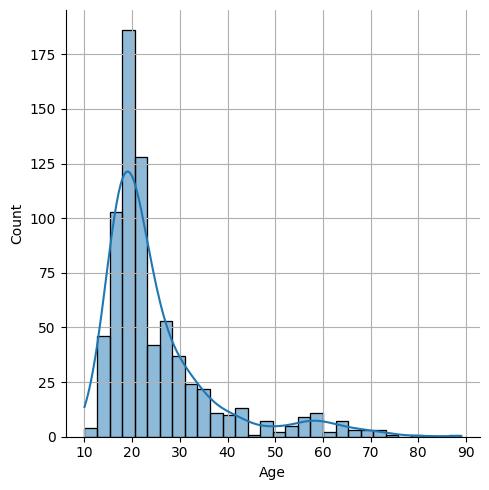

In [19]:
sns.displot(mental_health["Age"], kde=True, bins=30)
plt.grid()
plt.show()

## jointplot

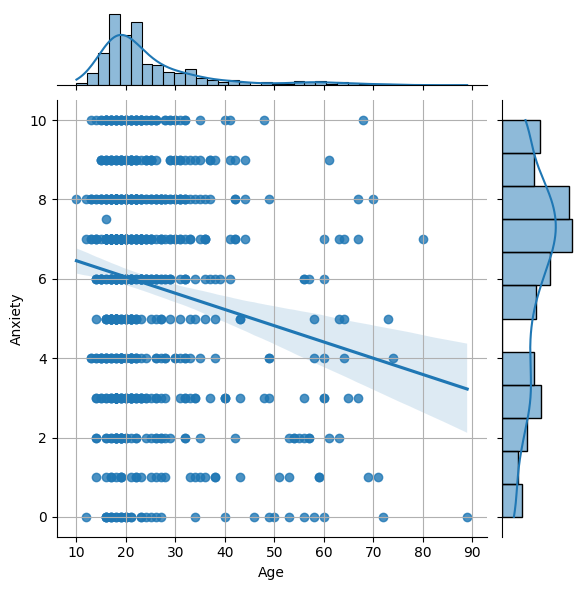

In [21]:
sns.jointplot(x="Age", y="Anxiety", data=mental_health, kind="reg")
plt.grid(True)
plt.show()

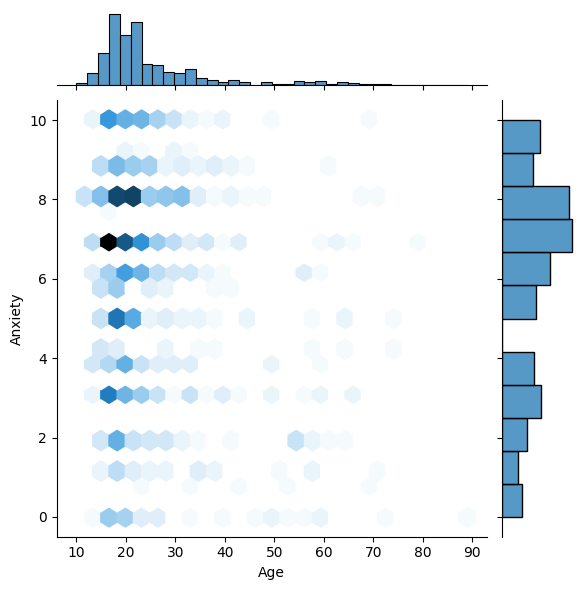

In [24]:
sns.jointplot(x="Age", y="Anxiety", data=mental_health, kind="hex")


## pairplot

pairplot will plot pairwise relationships across an entire dataframe (for the numerical columns) and supports a color hue argument (for categorical columns). 

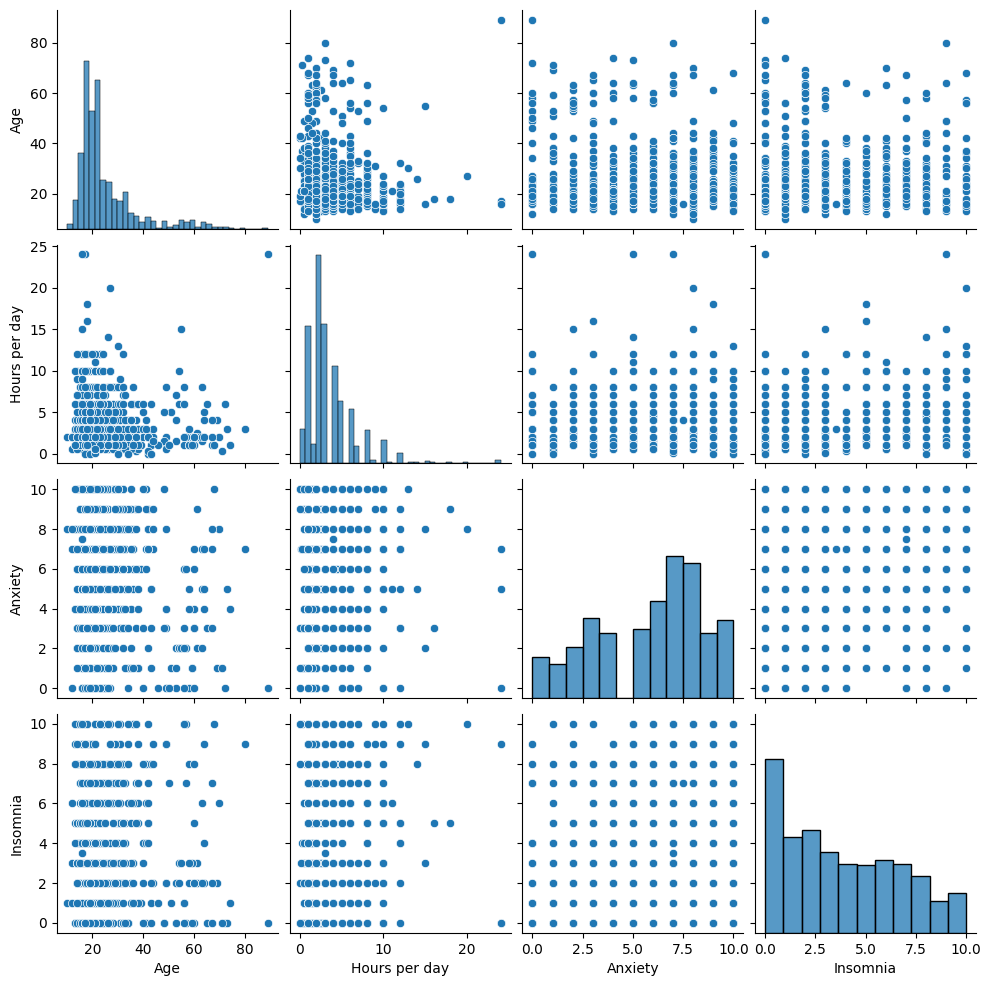

In [32]:
sns.pairplot(mental_health.drop(columns=["BPM", "OCD", "Depression"]))
plt.show()

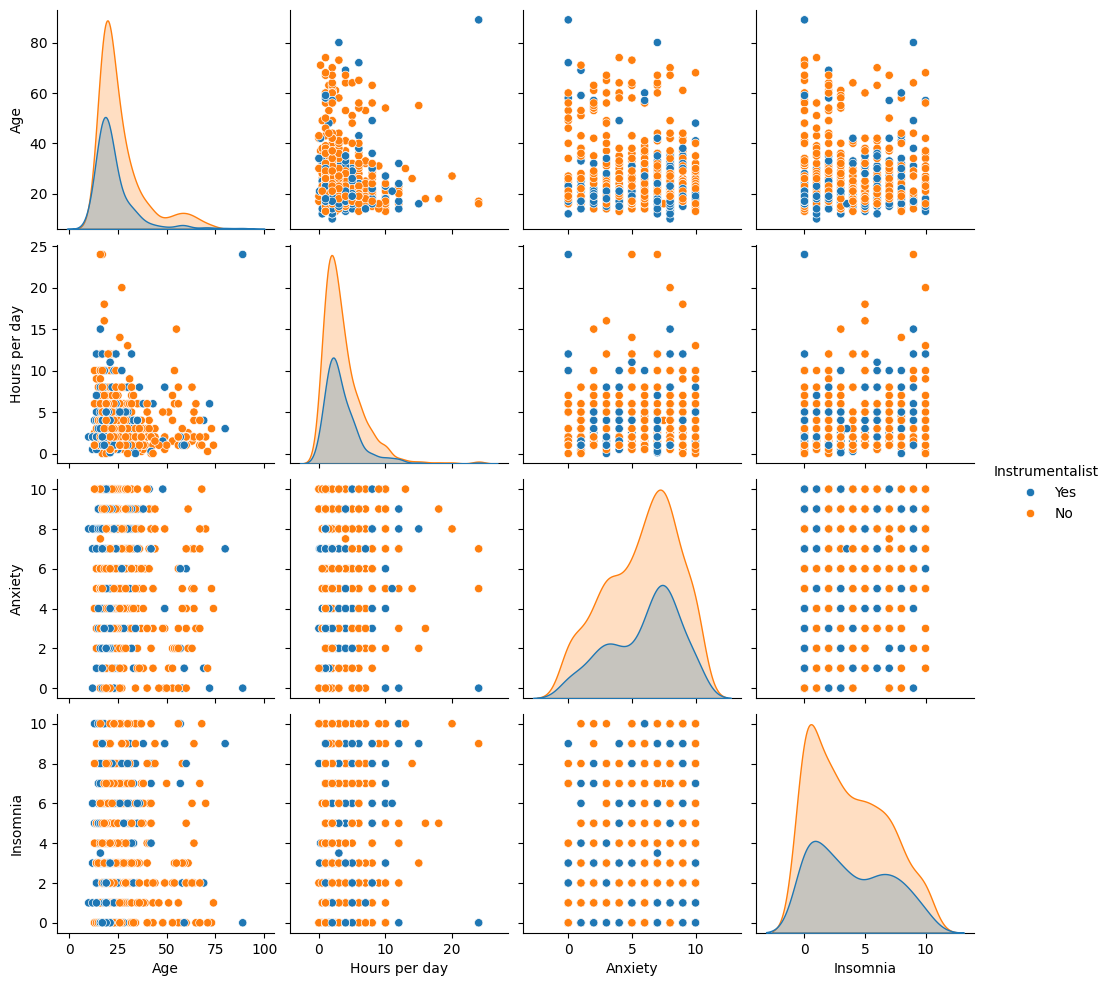

In [34]:
sns.pairplot(mental_health.drop(columns=["BPM", "OCD", "Depression"]), hue="Instrumentalist")
plt.show()

## rugplot

rugplots are actually a very simple concept, they just draw a dash mark for every point on a univariate distribution. They are the building block of a KDE plot:

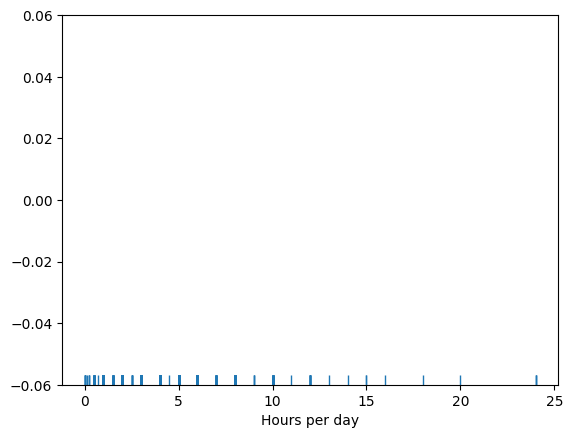

In [35]:
sns.rugplot(mental_health['Hours per day'])
plt.show()

## kdeplot

kdeplots are [Kernel Density Estimation plots](http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth). These KDE plots replace every single observation with a Gaussian (Normal) distribution centered around that value. For example:

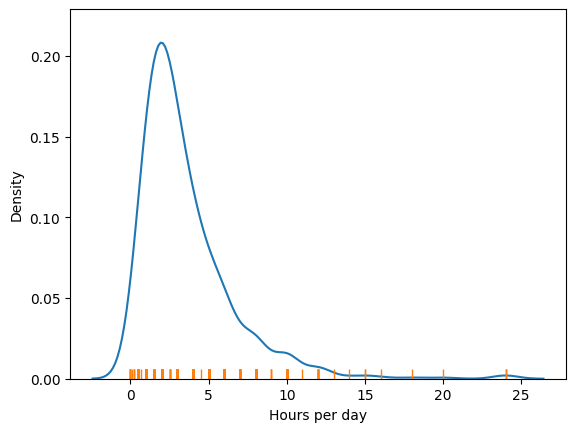

In [36]:
sns.kdeplot(mental_health['Hours per day'])
sns.rugplot(mental_health['Hours per day'])
plt.show()

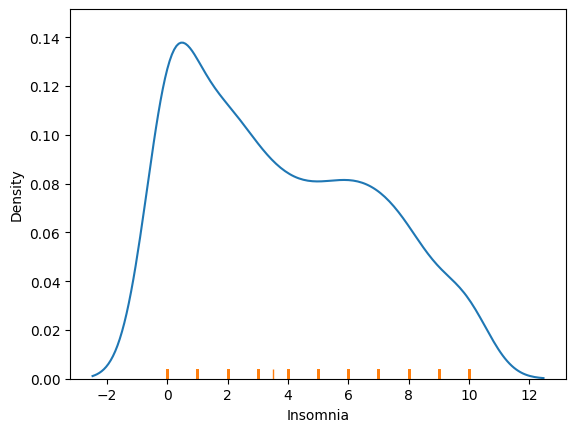

In [39]:
sns.kdeplot(mental_health['Insomnia'])
sns.rugplot(mental_health['Insomnia'])
plt.show()

# Categorical Plots

## barplot and countplot

These very similar plots allow you to get aggregate data off a categorical feature in your data. **barplot** is a general plot that allows you to aggregate the categorical data based off some function, by default the mean:

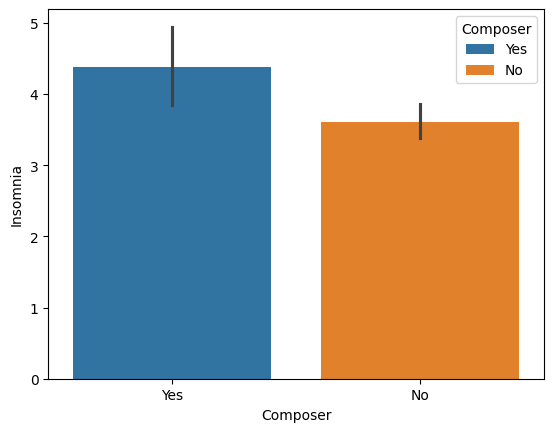

In [51]:
sns.barplot(x="Composer", y="Insomnia", data=mental_health, hue="Composer");

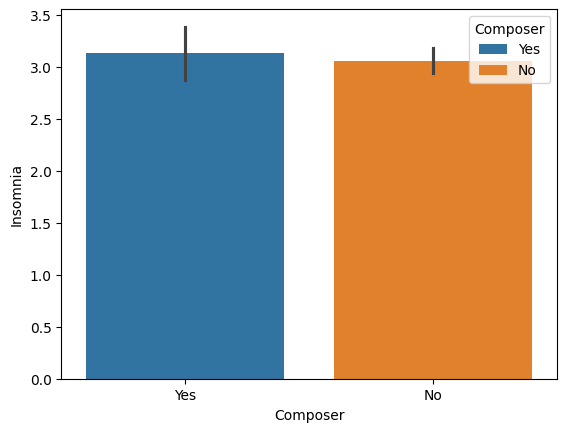

In [52]:
sns.barplot(x="Composer", y="Insomnia", data=mental_health, estimator=np.std, hue="Composer");

### countplot

This is essentially the same as barplot except the estimator is explicitly counting the number of occurrences. Which is why we only pass the x value:

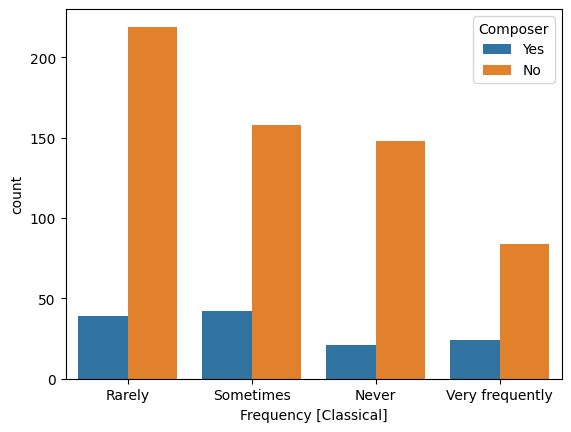

In [55]:
sns.countplot(x="Frequency [Classical]", data=mental_health, hue="Composer");

## boxplot and violinplot

boxplots and violinplots are used to shown the distribution of categorical data. A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

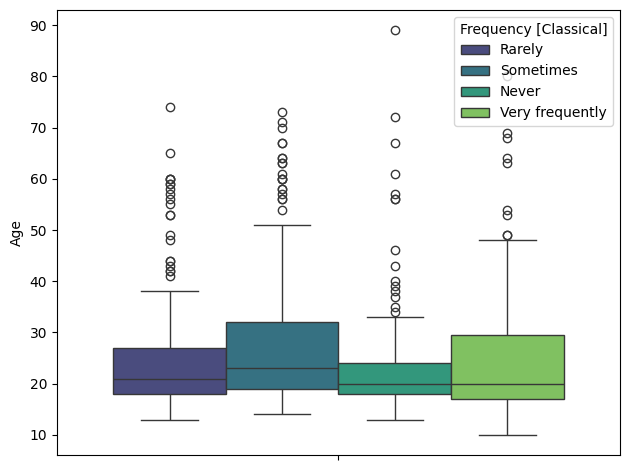

In [60]:
sns.boxplot(y="Age", data=mental_health, hue="Frequency [Classical]", palette='viridis')
plt.tight_layout()

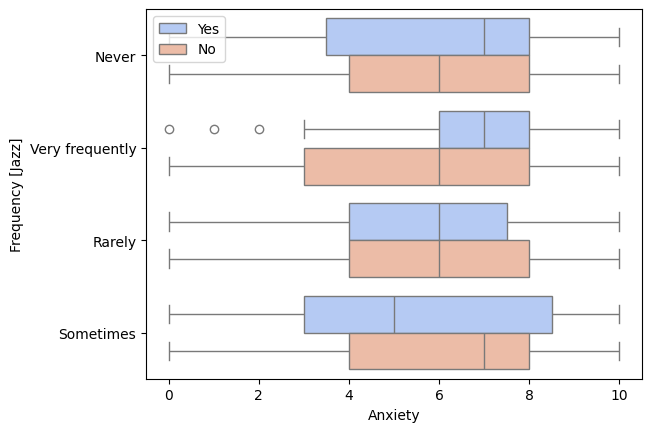

In [66]:
sns.boxplot(x="Anxiety", y="Frequency [Jazz]", hue="Composer",data=mental_health, palette="coolwarm")
plt.legend(loc="upper left")

### violinplot
A violin plot plays a similar role as a box and whisker plot. It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

<Axes: xlabel='Frequency [Jazz]', ylabel='Anxiety'>

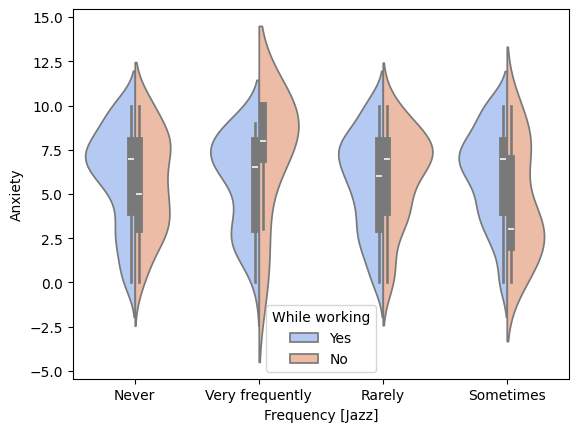

In [71]:
sns.violinplot( x="Frequency [Jazz]", y="Anxiety", data=mental_health, split=True, hue="While working", palette='coolwarm')

# Matrix Plots

In [74]:
mental_health.corr(numeric_only=True)

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
Age,1.000000,-0.044638,-0.029928,-0.176662,-0.121563,0.006909,-0.130114
Hours per day,-0.044638,1.000000,0.042554,0.049319,0.110527,0.141821,0.118729
BPM,-0.029928,0.042554,1.000000,-0.027050,0.041371,0.053591,0.018927
Anxiety,-0.176662,0.049319,-0.027050,1.000000,0.519969,0.292669,0.348350
Depression,-0.121563,0.110527,0.041371,0.519969,1.000000,0.378996,0.196988
Insomnia,0.006909,0.141821,0.053591,0.292669,0.378996,1.000000,0.226354
OCD,-0.130114,0.118729,0.018927,0.348350,0.196988,0.226354,1.000000


<Axes: >

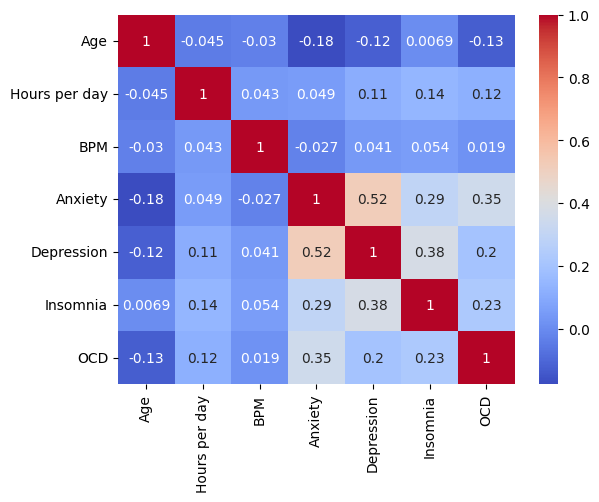

In [76]:
sns.heatmap(mental_health.corr(numeric_only=True), cmap='coolwarm',annot=True)

In [78]:
mental_health.pivot_table(values="Hours per day", index="Depression", columns="Anxiety")

Anxiety,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,7.5,8.0,9.0,10.0
Depression,,,,,,,,,,,,
0.0,3.950000,3.354167,4.769231,3.178571,2.916667,NaN,2.400000,2.250000,NaN,2.250000,4.250000,1.500000
1.0,5.500000,2.437500,4.083333,4.666667,3.833333,5.666667,2.300000,2.500000,NaN,NaN,4.000000,1.000000
2.0,3.166667,2.166667,3.269231,3.208333,3.090909,4.000000,2.611111,4.464286,NaN,3.500000,4.000000,1.800000
3.0,7.500000,2.500000,4.333333,2.625000,3.000000,1.416667,1.785714,3.125000,NaN,2.333333,3.250000,3.625000
3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,2.000000
4.0,3.000000,NaN,2.000000,1.875000,2.200000,3.200000,3.307692,2.727273,NaN,1.928571,6.250000,1.000000
5.0,3.500000,3.000000,NaN,3.666667,1.750000,3.583333,2.954545,3.477778,4.0,2.357143,6.000000,2.500000
6.0,1.000000,3.000000,5.500000,1.333333,2.500000,3.870000,2.818182,3.562500,NaN,4.281250,3.875000,3.833333
7.0,NaN,2.000000,2.500000,5.071429,4.300000,4.714286,4.555556,2.933333,NaN,3.884615,3.187500,3.642857


<Axes: xlabel='Frequency [Pop]', ylabel='Hours per day'>

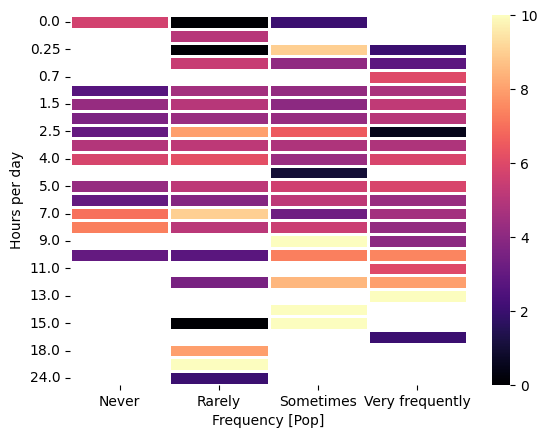

In [84]:
pvhealth = mental_health.pivot_table(values="Depression", index="Hours per day", columns="Frequency [Pop]")
sns.heatmap(pvhealth, cmap="magma", linecolor='white',linewidths=1)